In [130]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import matplotlib.colors as colors
import metpy.calc as mpcalc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# %run ../Feedback/Pendergrass-function.ipynb
%run Temperature_feedback_function.ipynb
%run Water_vapor_feedback_function.ipynb
%run Albedo_feedback_function.ipynb
%run Cloud_feedback_function.ipynb
%run Plank_feedback_function.ipynb
%run LP_rate_feedback_function.ipynb
%run ../functions/Weighted_area_mean.ipynb
%run ../functions/Transfer_longitude.ipynb
%run ../functions/mask_land_ocean.ipynb

## Calculate feedbacks

### Read the basic fields

In [131]:
time_begin='1979-01-01'
time_end  ='2020-12-01'
#=======================ts===================================
diri='/zhoulab_rit/lzhuo/data/Modelling/CTL/'
filename='TS.nc'
fi=xr.open_dataset(diri+filename)
ts=fi.TS
ts['time']=pd.date_range(time_begin,time_end,freq='MS')
#======================ta=======================================
filename='T.plev.nc'
fi=xr.open_dataset(diri+filename)
ta=fi.T
ta['time']=pd.date_range(time_begin,time_end,freq='MS')
#=======================Q====================================
filename='Q.plev.nc'
fi=xr.open_dataset(diri+filename)
Q=fi.Q
Q['time']=pd.date_range(time_begin,time_end,freq='MS')
#================BOA net solar flux at surface========================
filename='FSNS.nc'
fi=xr.open_dataset(diri+filename)
FSNS=fi.FSNS
FSNS['time']=pd.date_range(time_begin,time_end,freq='MS')
#================BOA net longwave flux at surface========================
filename='FLNS.nc'
fi=xr.open_dataset(diri+filename)
FLNS=fi.FLNS
FLNS['time']=pd.date_range(time_begin,time_end,freq='MS')
#=================BOA downward solar flux at surface==================
filename='FSDS.nc'
fi=xr.open_dataset(diri+filename)
FSDS=fi.FSDS
FSDS['time']=pd.date_range(time_begin,time_end,freq='MS')
#================TOA Net longwave radiation (positive:up)=================
filename='FLNT.nc'
fi=xr.open_dataset(diri+filename)
FLNT=fi.FLNT
#rearrange the time coordinate
FLNT['time']=pd.date_range(time_begin,time_end,freq='MS')
#================TOA Net shortwave radiation (positive:down)===============
filename='FSNT.nc'
fi=xr.open_dataset(diri+filename)
FSNT=fi.FSNT
#rearrange the time coordinate
FSNT['time']=pd.date_range(time_begin,time_end,freq='MS')
#=======================LW cloud forcing=============================
filename='LWCF.nc'
fi=xr.open_dataset(diri+filename)
LWCF=fi.LWCF
LWCF['time']=pd.date_range(time_begin,time_end,freq='MS')
#=======================SW cloud forcing==============================
filename='SWCF.nc'
fi=xr.open_dataset(diri+filename)
SWCF=fi.SWCF
SWCF['time']=pd.date_range(time_begin,time_end,freq='MS')
#=====================Sensible heat flux==============================
filename='SHFLX.nc'
fi=xr.open_dataset(diri+filename)
SHFLX=fi.SHFLX
#rearrange the time coordinate
SHFLX['time']=pd.date_range(time_begin,time_end,freq='MS')
#======================Latent heat flux================================
filename='LHFLX.nc'
fi=xr.open_dataset(diri+filename)
LHFLX=fi.LHFLX
#rearrange the time coordinate
LHFLX['time']=pd.date_range(time_begin,time_end,freq='MS')
# #==========================cloud masking=============================
# diri='/zhoulab_rit/lzhuo/data/Pendergrass_kernel/'
# filename='aerosol.forcing.nc';
# fi=xr.open_dataset(diri+filename)
# sw   =fi.FSNT
# sw_cs=fi.FSNTC
# lw   =fi.FLNT
# lw_cs=fi.FLNTC
# aerosol_sw=sw_cs-sw
# aerosol_lw=lw_cs-lw

# filename='ghg.forcing.nc';
# fi=xr.open_dataset(diri+filename)
# sw   =fi.FSNT
# sw_cs=fi.FSNTC
# lw   =fi.FLNT
# lw_cs=fi.FLNTC
# ghg_sw=sw_cs-sw
# ghg_lw=lw_cs-lw

# cloud_masking_of_forcing_sw=aerosol_sw+ghg_sw
# cloud_masking_of_forcing_lw=aerosol_lw+ghg_lw

### Take the difference

In [132]:
def difference(var):
    # first period
    var1=var.sel(time=slice('1979-01-01','1988-12-01'))
    var1_month=var1.groupby("time.month").mean()
    # second period
    var2=var.sel(time=slice('2011-01-01','2020-12-01'))
    var2_month=var2.groupby("time.month").mean()
    dvar=var2_month-var1_month
    return var1_month,var2_month,dvar

In [133]:
Q1,Q2,dq                            =difference(Q)
T1,T2,dta                           =difference(ta)
ts2,ts2,dts                         =difference(ts)
SW_sfc_net_1,SW_sfc_net_2,dFSNS     =difference(FSNS)
SW_sfc_down_1,SW_sfc_down_2,dFSDS   =difference(FSDS)
SWCF1,SWCF2,dSWCF                   =difference(SWCF)
LWCF1,LWCF2,dLWCF                   =difference(LWCF)

/knight/anaconda_aug22/envs/aug22_env/lib/python3.10/site-packages/flox/aggregate_flox.py:105: RuntimeWarning: invalid value encountered in true_divide
  out /= nanlen(group_idx, array, size=size, axis=axis, fill_value=0)
/knight/anaconda_aug22/envs/aug22_env/lib/python3.10/site-packages/flox/aggregate_flox.py:105: RuntimeWarning: invalid value encountered in true_divide
  out /= nanlen(group_idx, array, size=size, axis=axis, fill_value=0)
/knight/anaconda_aug22/envs/aug22_env/lib/python3.10/site-packages/flox/aggregate_flox.py:105: RuntimeWarning: invalid value encountered in true_divide
  out /= nanlen(group_idx, array, size=size, axis=axis, fill_value=0)
/knight/anaconda_aug22/envs/aug22_env/lib/python3.10/site-packages/flox/aggregate_flox.py:105: RuntimeWarning: invalid value encountered in true_divide
  out /= nanlen(group_idx, array, size=size, axis=axis, fill_value=0)


### Change in albedo

In [134]:
#----------------------albedo at two states----------------------------------------------
alb1=1-SW_sfc_net_1/SW_sfc_down_1
alb2=1-SW_sfc_net_2/SW_sfc_down_2
#----------------------change in albedo--------------------------------------------------
dalb=(alb2-alb1)*100

### Calculate the change in BOA energy flux and AHET

In [135]:
#-------------TOA net radiation (positive:down)--------------------------
net=FSNT-FLNT
#-------------TOA gain--------------------------------------------------
net1,net2,TOA_gain =difference(net)
#--------------BOA net radiation and total heat flux------------------------------------------
net=FLNS-FSNS           #positive:up
tot_heatflx=SHFLX+LHFLX #positive:up
tot=net+tot_heatflx     #positive:up
#--------------Take the difference----------------------------------------------------------
tot1,tot2,BOA_gain =difference(tot)
#--------------Change in AHET---------------------------------------------
delta_AHET=-(TOA_gain+BOA_gain)

### Calculate the radiative forcing and cloud masking from NOSST

In [136]:
diri='/zhoulab_rit/lzhuo/data/Modelling/AMIP_NOSST/'
filename='FLNT.nc'
fi=xr.open_dataset(diri+filename)
FLNT=fi.FLNT
FLNT['time']=pd.date_range('1979-01-01','2021-12-01',freq='MS')
#-----------------Net shortwave radiation (positive:down)-------------------------
filename='FSNT.nc'
fi=xr.open_dataset(diri+filename)
FSNT=fi.FSNT
FSNT['time']=pd.date_range('1979-01-01','2021-12-01',freq='MS')
#-----------------Clearsky net longwave radiation-------------------------------
filename='FLNTC.nc'
fi=xr.open_dataset(diri+filename)
FLNTC=fi.FLNTC
FLNTC['time']=pd.date_range('1979-01-01','2021-12-01',freq='MS')
#-----------------Clearsky net shortwave radiation---------------------------------
filename='FSNTC.nc'
fi=xr.open_dataset(diri+filename)
FSNTC=fi.FSNTC
FSNTC['time']=pd.date_range('1979-01-01','2021-12-01',freq='MS')
#------------------Calculate the net radiation and radiative forcing-------------------------------
net=FSNT-FLNT
net1,net2,RF =difference(net)
#------------------Calculate the cloud masking-------------------------------------
net=FSNTC-FSNT
net1,net2,cloud_masking_of_forcing_sw=difference(net)
net=FLNTC-FLNT
net1,net2,cloud_masking_of_forcing_lw=difference(net)

### Do the calculation

In [137]:
#---------------------water vapor feedback-------------------------------------
dLW_q,dSW_q,total_q,dLW_q_cs,dSW_q_cs,total_q_cs=wv_feedback(Q1,T1,T2,dta,dq)
#---------------------Plank feedback-------------------------------------
R_Plank=Pk_feedback(dts)
#---------------------Lapse rate feedback---------------------------------
R_LP=LP_feedback(dts,dta)
#---------------------Albedo feedback-------------------------------------
dSW_alb,dSW_alb_cs=alb_feedback(dalb)
#---------------------Temperature feedback--------------------------------
dLW_t,dLW_t_cs=T_feedback(dts,dta)
#---------------------Cloud feedback-------------------------------------
dLW_cloud,dSW_cloud,total_cloud=cld_feedback(cloud_masking_of_forcing_sw,cloud_masking_of_forcing_lw,
                dSWCF,dLWCF,
                dSW_q_cs,dSW_q,dSW_alb_cs,dSW_alb,
                dLW_q_cs,dLW_q,dLW_t_cs,dLW_t)

## Calculate the global mean Plank feedback parameter

In [138]:
def weighted_area_mean(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"
    air_weighted = ds.weighted(weights)
    weighted_mean = air_weighted.mean(("lon", "lat"))
    return weighted_mean

def feedback_parameter(F,dts):
    F_area_mean  =weighted_area_mean(F)
    dts_area_mean=weighted_area_mean(dts)
    lambna=F_area_mean/dts_area_mean
    return lambna

R_annual_mean=-R_Plank.sel(month=slice(6,11)).mean(dim='month') #positive: downward
dts_annual_mean=dts.sel(month=slice(6,11)).mean(dim='month')
lambna0_bar=feedback_parameter(R_annual_mean,dts_annual_mean)
lambna0_bar

<xarray.DataArray ()>
array(-3.32571516)

In [139]:
RF          =central180_to_0(RF)
R_Plank     =central180_to_0(R_Plank)
dLW_q       =central180_to_0(dLW_q)
dSW_q       =central180_to_0(dSW_q)
R_LP        =central180_to_0(R_LP)
delta_AHET  =central180_to_0(delta_AHET)
dtot        =central180_to_0(BOA_gain)
total_cloud =central180_to_0(total_cloud)
dts         =central180_to_0(dts)

### Mask out the ocean and leave only the land

In [148]:
RF_land=mask_ocean(RF.sel(month=slice(6,11)).mean(dim='month'))
PL_land=mask_ocean(R_Plank.sel(month=slice(6,11)).mean(dim='month'))
dLW_q_land=mask_ocean(dLW_q.sel(month=slice(6,11)).mean(dim='month'))
dSW_q_land=mask_ocean(dSW_q.sel(month=slice(6,11)).mean(dim='month'))
LP_land=mask_ocean(R_LP.sel(month=slice(6,11)).mean(dim='month'))
AHET_land=mask_ocean(delta_AHET.sel(month=slice(6,11)).mean(dim='month'))
dtot_land=mask_ocean(dtot.sel(month=slice(6,11)).mean(dim='month'))
cloud_land=mask_ocean(total_cloud.sel(month=slice(6,11)).mean(dim='month'))
dts_land=mask_ocean(dts.sel(month=slice(6,11)).mean(dim='month'))

### Mask out the Sahara Desert

In [163]:
# define the regional mask
def def_mask(var):
    # var: 2d variable 
    Sahara_mask=var.copy()
    Sahara_mask.values=0 * Sahara_mask.values
    mask=Sahara_mask.where((Sahara_mask.lat<=30)&(Sahara_mask.lat>=20)&(Sahara_mask.lon>=-10)&(Sahara_mask.lon<=30),1)
    return mask
# mask out the Sahara Desert
mask=def_mask(PL_land)
PL_land_noSahara=PL_land.where(mask>0)
dLW_q_land_noSahara=dLW_q_land.where(mask>0)
dSW_q_land_noSahara=dSW_q_land.where(mask>0)
LP_land_noSahara=LP_land.where(mask>0)
cloud_land_noSahara=cloud_land.where(mask>0)

mask=def_mask(AHET_land)
RF_land_noSahara=RF_land.where(mask>0)
AHET_land_noSahara=AHET_land.where(mask>0)
dtot_land_noSahara=dtot_land.where(mask>0)
dts_land_noSahara=dts_land.where(mask>0)

In [167]:
Sahara_RF   =RF.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_PL   =-R_Plank.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_LW_q =-dLW_q.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_SW_q =dSW_q.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_LP   =-R_LP.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_AHET =delta_AHET.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_heat =dtot.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_cloud=total_cloud.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')
Sahara_dts  =dts.sel(month=slice(6,11),lat=slice(20,30),lon=slice(-10,30)).mean(dim='month')

Tropics_RF_land   =RF_land.sel(lat=slice(-30,30))
Tropics_PL_land   =-PL_land.sel(lat=slice(-30,30))
Tropics_LW_q_land =-dLW_q_land.sel(lat=slice(-30,30))
Tropics_SW_q_land =dSW_q_land.sel(lat=slice(-30,30))
Tropics_LP_land   =-LP_land.sel(lat=slice(-30,30))
Tropics_AHET_land =AHET_land.sel(lat=slice(-30,30))
Tropics_heat_land =dtot_land.sel(lat=slice(-30,30))
Tropics_cloud_land=cloud_land.sel(lat=slice(-30,30))
Tropics_dts_land  =dts_land.sel(lat=slice(-30,30))

Tropics_RF_land_noSahara   =RF_land_noSahara.sel(lat=slice(-30,30))
Tropics_PL_land_noSahara   =-PL_land_noSahara.sel(lat=slice(-30,30))
Tropics_LW_q_land_noSahara =-dLW_q_land_noSahara.sel(lat=slice(-30,30))
Tropics_SW_q_land_noSahara =dSW_q_land_noSahara.sel(lat=slice(-30,30))
Tropics_LP_land_noSahara   =-LP_land_noSahara.sel(lat=slice(-30,30))
Tropics_AHET_land_noSahara =AHET_land_noSahara.sel(lat=slice(-30,30))
Tropics_heat_land_noSahara =dtot_land_noSahara.sel(lat=slice(-30,30))
Tropics_cloud_land_noSahara=cloud_land_noSahara.sel(lat=slice(-30,30))
Tropics_dts_land_noSahara  =dts_land_noSahara.sel(lat=slice(-30,30))

In [168]:
Sahara_RF     = weighted_area_mean(Sahara_RF)
Sahara_PL     = weighted_area_mean(Sahara_PL)
Sahara_LW_q   = weighted_area_mean(Sahara_LW_q)
Sahara_SW_q   = weighted_area_mean(Sahara_SW_q)
Sahara_LP     = weighted_area_mean(Sahara_LP)
Sahara_heat   = weighted_area_mean(Sahara_heat)
Sahara_AHET   = weighted_area_mean(Sahara_AHET)
Sahara_cloud  = weighted_area_mean(Sahara_cloud)
Sahara_dts    = weighted_area_mean(Sahara_dts)

Tropics_RF_land     = weighted_area_mean(Tropics_RF_land)
Tropics_PL_land     = weighted_area_mean(Tropics_PL_land)
Tropics_LW_q_land   = weighted_area_mean(Tropics_LW_q_land)
Tropics_SW_q_land   = weighted_area_mean(Tropics_SW_q_land)
Tropics_LP_land     = weighted_area_mean(Tropics_LP_land)
Tropics_heat_land   = weighted_area_mean(Tropics_heat_land)
Tropics_AHET_land   = weighted_area_mean(Tropics_AHET_land)
Tropics_cloud_land  = weighted_area_mean(Tropics_cloud_land)
Tropics_dts_land    = weighted_area_mean(Tropics_dts_land)

Tropics_RF_land_noSahara     = weighted_area_mean(Tropics_RF_land_noSahara)
Tropics_PL_land_noSahara     = weighted_area_mean(Tropics_PL_land_noSahara)
Tropics_LW_q_land_noSahara   = weighted_area_mean(Tropics_LW_q_land_noSahara)
Tropics_SW_q_land_noSahara   = weighted_area_mean(Tropics_SW_q_land_noSahara)
Tropics_LP_land_noSahara     = weighted_area_mean(Tropics_LP_land_noSahara)
Tropics_heat_land_noSahara   = weighted_area_mean(Tropics_heat_land_noSahara)
Tropics_AHET_land_noSahara   = weighted_area_mean(Tropics_AHET_land_noSahara)
Tropics_cloud_land_noSahara  = weighted_area_mean(Tropics_cloud_land_noSahara)
Tropics_dts_land_noSahara    = weighted_area_mean(Tropics_dts_land_noSahara)

In [170]:
#----------------------------Taking the Plank feedback into consideration--------------------------------------
def energy_budget(RF,R_PL,R_LW_WV,R_SW_WV,R_LP,delta_OHU,delta_A,R_Cloud,dts,lambda_bar):
    #lambda_bar: global mean Plank feedback parameter
    lambda0=R_PL/dts
    lambda_ano=lambda0-lambda_bar
    R_PL_ano=lambda_ano*dts
    Feedback_R=np.array([RF,R_PL_ano,R_LW_WV,R_SW_WV,R_LP,R_Cloud,delta_OHU,delta_A])
    Feedback_T= -np.divide(Feedback_R, np.array(lambda_bar))
    Res=dts-Feedback_T.sum()
    return Feedback_T,Res
#--------------------------------Sahara-------------------------------------------------
Feedback_T_Sahara,Res_Sahara=energy_budget(Sahara_RF,Sahara_PL,Sahara_LW_q,Sahara_SW_q,Sahara_LP,
                                           Sahara_heat,Sahara_AHET,Sahara_cloud,Sahara_dts,lambna0_bar)
Feedback_T_Tropics_land,Res_Tropics_land=energy_budget(Tropics_RF_land,Tropics_PL_land,Tropics_LW_q_land,Tropics_SW_q_land,Tropics_LP_land,
                                             Tropics_heat_land,Tropics_AHET_land,Tropics_cloud_land,Tropics_dts_land,lambna0_bar)
Feedback_T_Tropics_land_noSahara,Res_Tropics_land_noSahara=energy_budget(Tropics_RF_land_noSahara,Tropics_PL_land_noSahara,Tropics_LW_q_land_noSahara,
                                                                         Tropics_SW_q_land_noSahara,Tropics_LP_land_noSahara,
                                                                         Tropics_heat_land_noSahara,Tropics_AHET_land_noSahara,
                                                                         Tropics_cloud_land_noSahara,Tropics_dts_land_noSahara,lambna0_bar)

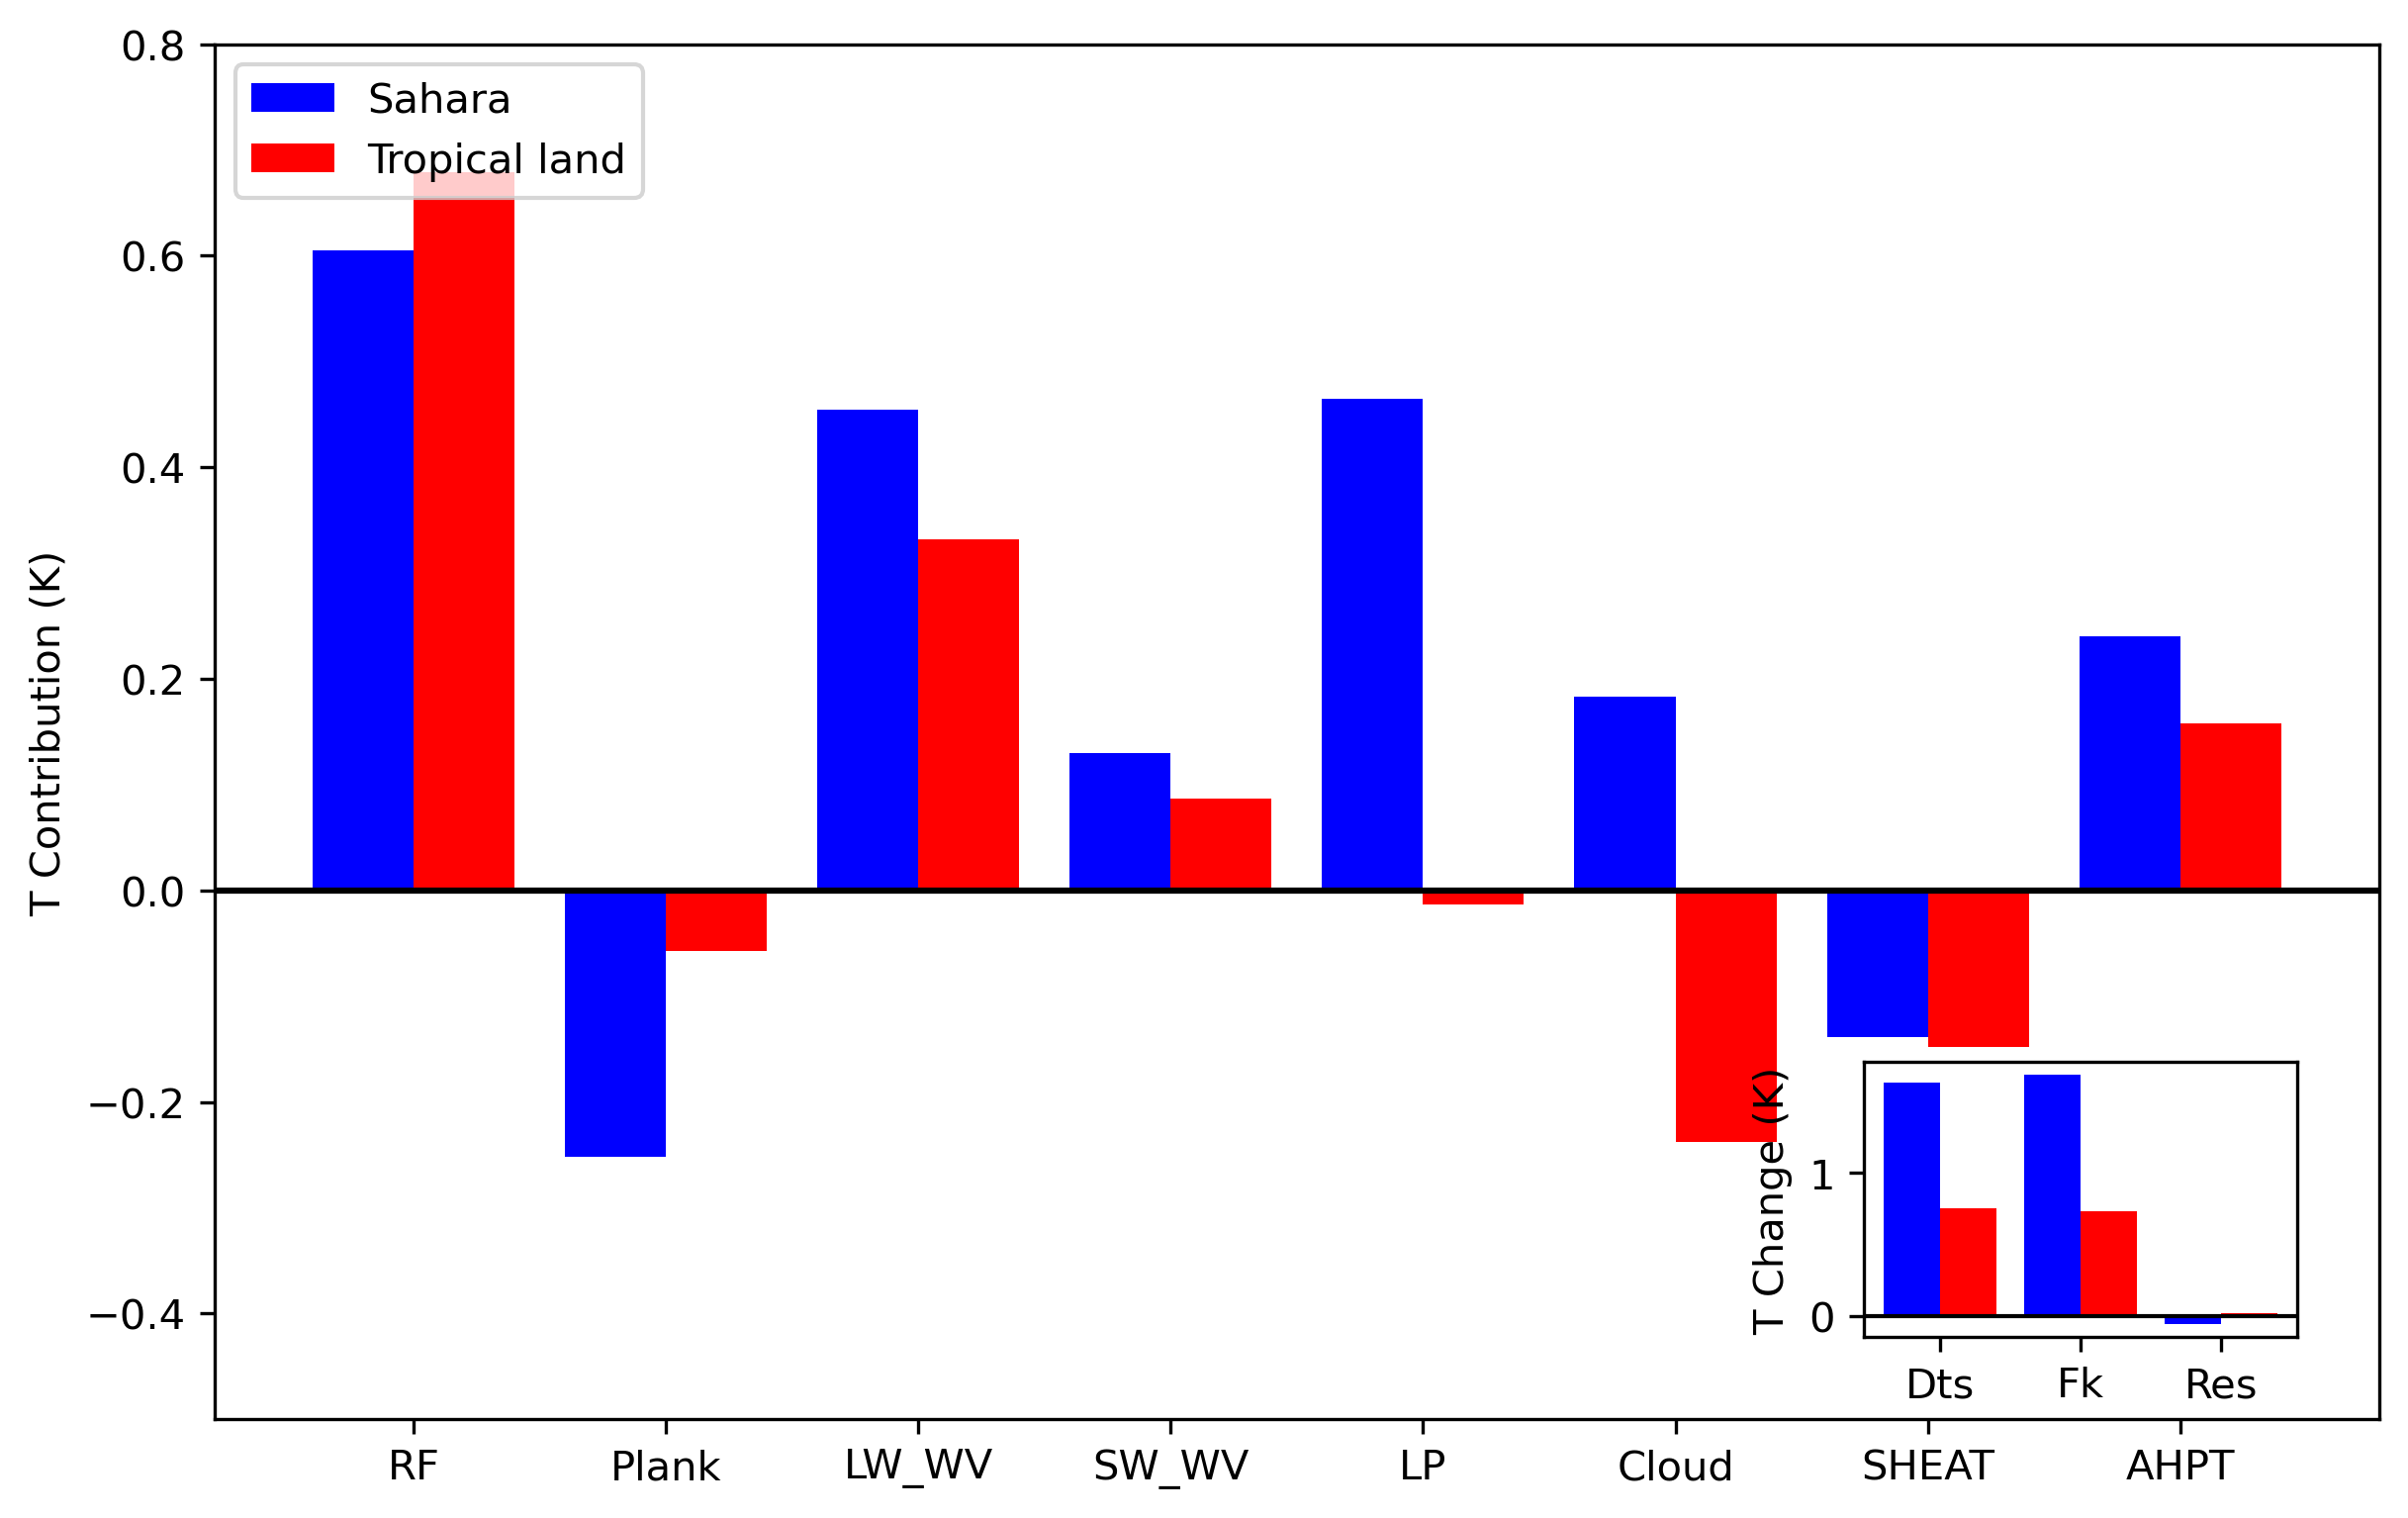

In [173]:
fig = plt.figure(figsize=(8, 5),dpi=300,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])
x=np.arange(1,9)
y=Feedback_T_Sahara.tolist()
width=0.4
ax.bar(x, y,color='blue',width=width,label='Sahara')
x=x+width
y=Feedback_T_Tropics_land.tolist()
ax.bar(x, y,color='red',width=width,label='Tropical land')
x=x-width/2
labels=['RF','Plank','LW_WV','SW_WV','LP','Cloud','SHEAT','AHPT']
ax.set_xticks(x, labels)
ax.set_ylabel('T Contribution (K)')
ax.set_ylim([-0.5,0.8])
ax.axhline(y = 0, color = 'k', linestyle = '-')
ax.legend(loc='upper left')

ax2 = inset_axes(ax, width="20%", height="20%", loc=4,borderpad=2)
x=np.arange(1,4)
y=[Sahara_dts,Feedback_T_Sahara.sum(),Res_Sahara]
width=0.4
ax2.bar(x, y,color='blue',width=width)
x=x+width
y=[Tropics_dts_land_noSahara,Feedback_T_Tropics_land_noSahara.sum(),Res_Tropics_land_noSahara]
ax2.bar(x, y,color='red',width=width)

labels=['Dts','Fk','Res']
x=x-width/2
ax2.set_xticks(x, labels)
ax2.set_ylabel('T Change (K)')
ax2.axhline(y = 0, color = 'k', linestyle = '-',linewidth=1)

Text(0, 0.5, 'T Contribution (K)')

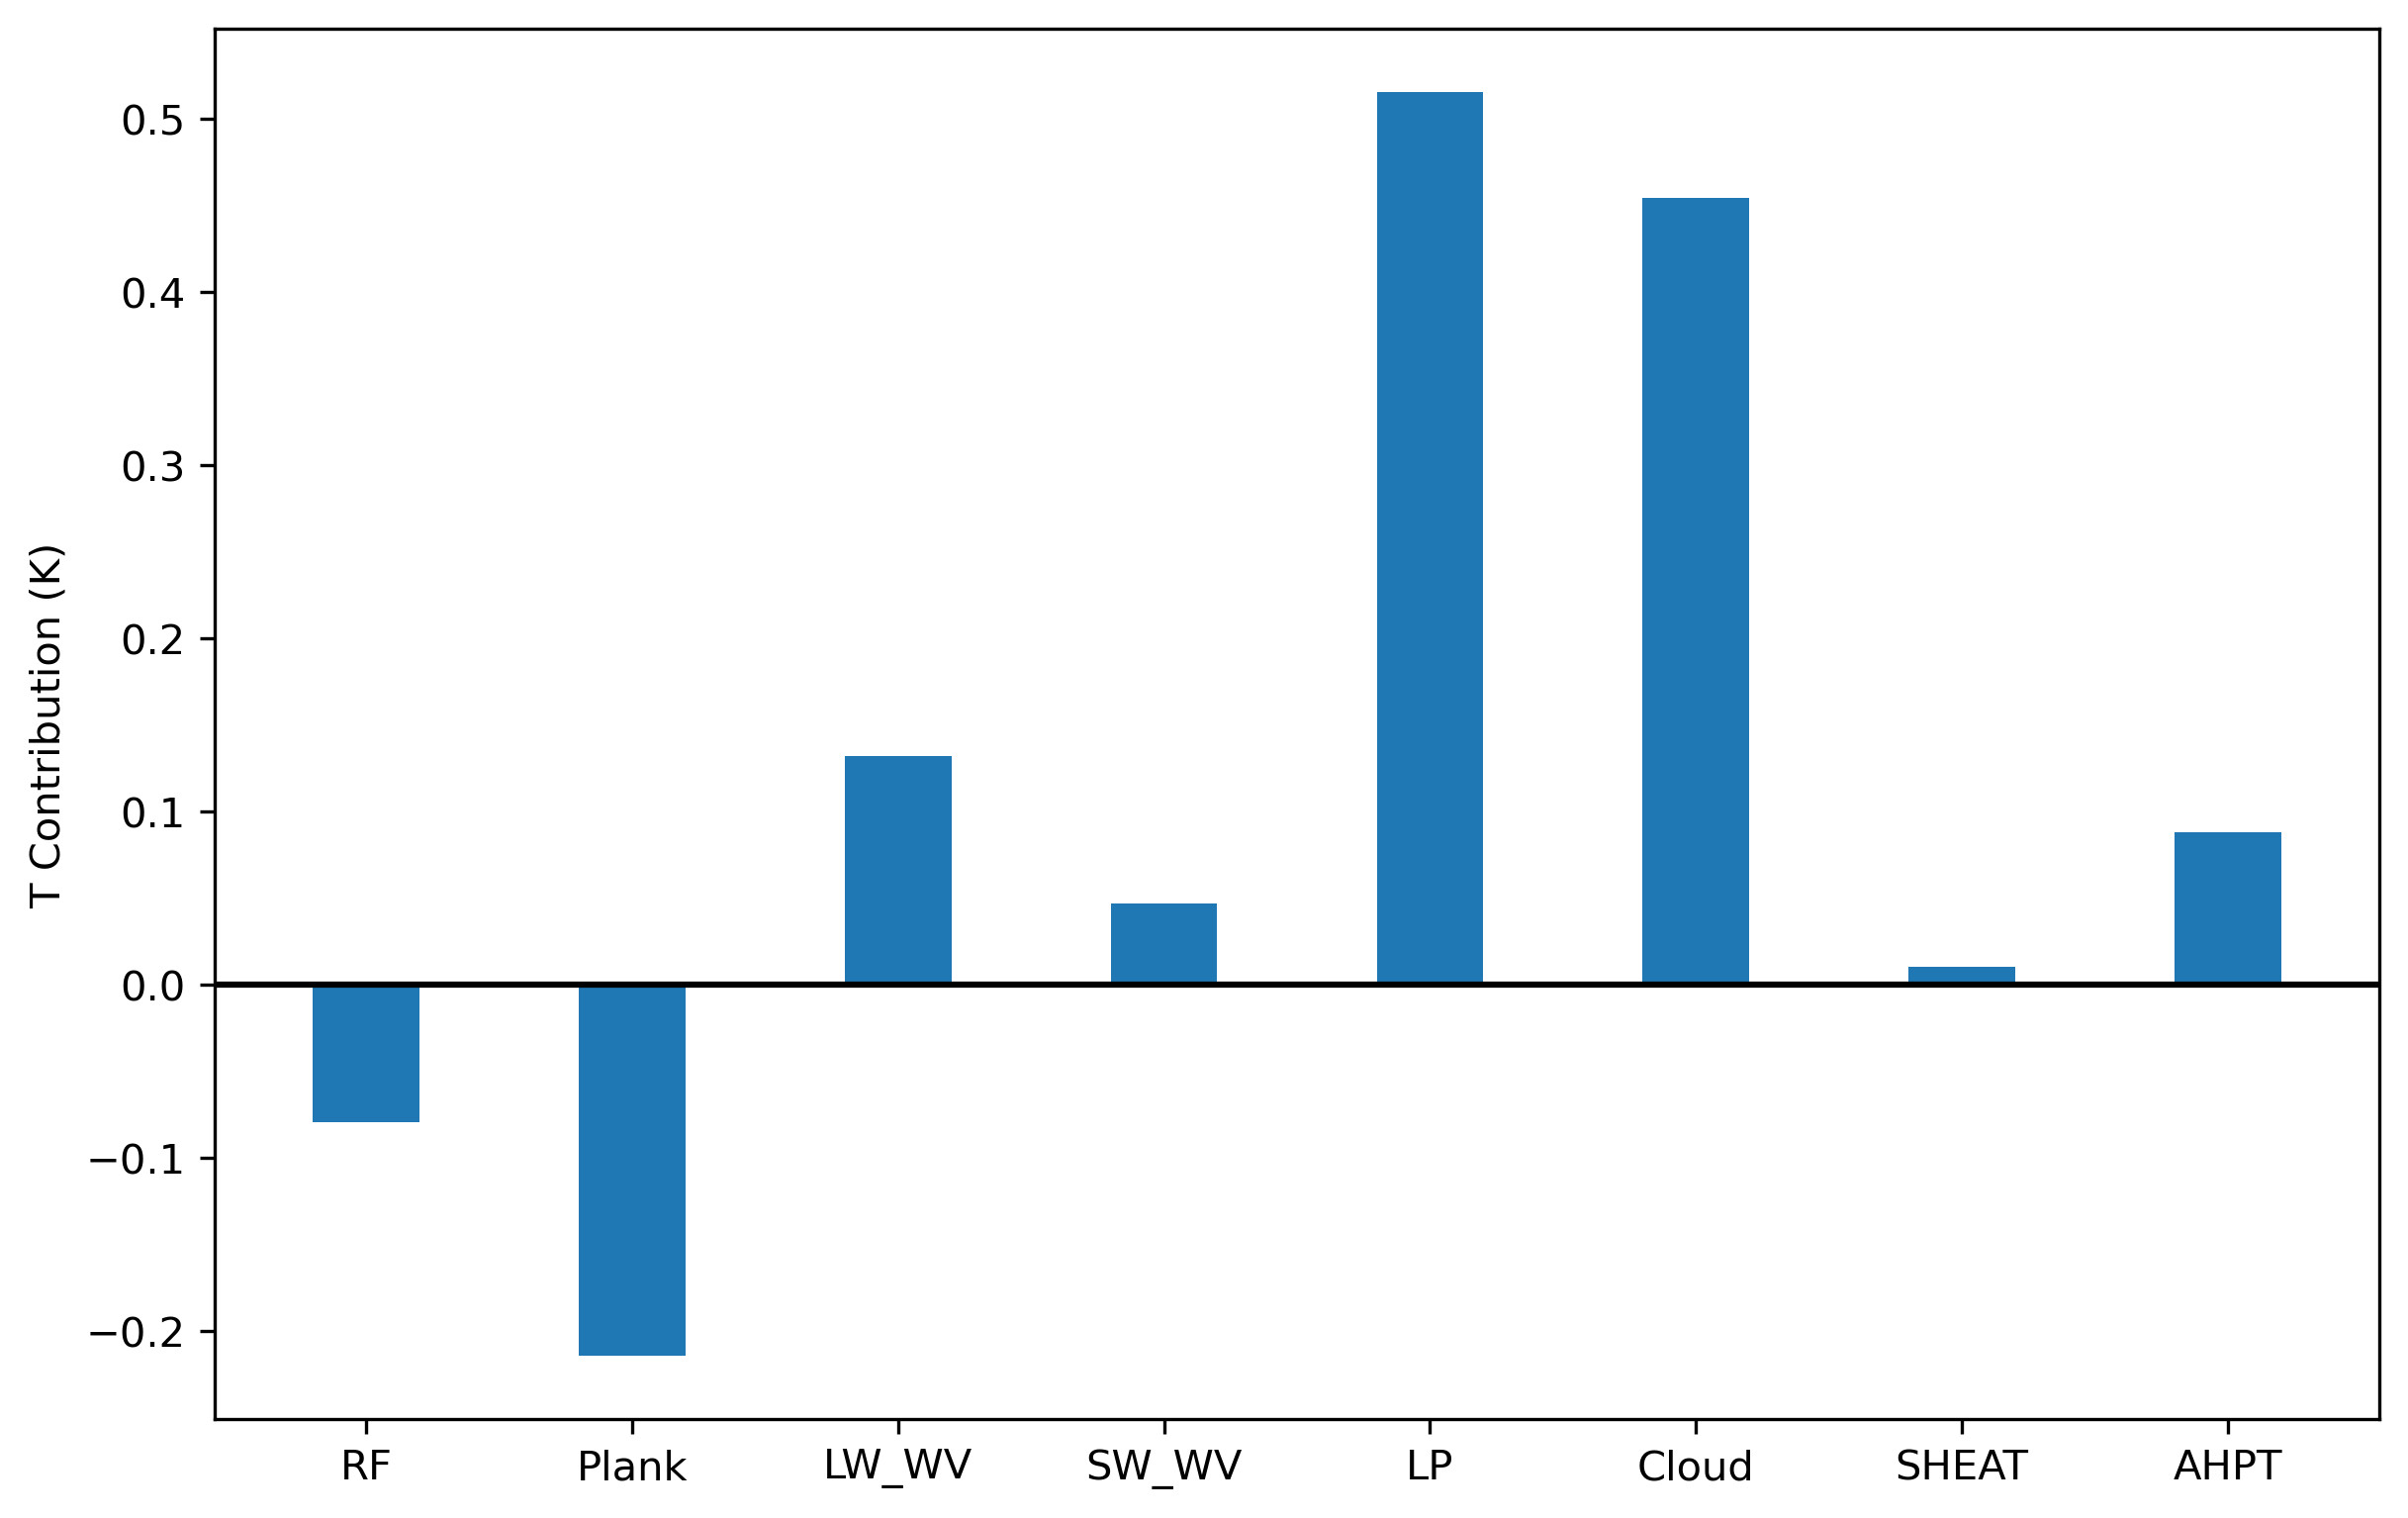

In [172]:
fig = plt.figure(figsize=(8, 5),dpi=300,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0])
x=np.arange(1,9)
y1=Feedback_T_Sahara
y2=Feedback_T_Tropics_land_noSahara
width=0.4
y=y1-y2
ax.bar(x, y,color='tab:blue',width=width)
ax.axhline(y=0,color='black')
# x=x+width
# y2=Feedback_T_Tropics_land_noSahara.tolist()
# ax.bar(x, y,color='red',width=width,label='Tropical land')
# x=x-width/2
labels=['RF','Plank','LW_WV','SW_WV','LP','Cloud','SHEAT','AHPT']
ax.set_xticks(x, labels)
ax.set_ylabel('T Contribution (K)')